# Fase 19-20: Robustez, ética, privacidad y seguridad

## 19. Robustez y generalización

- **Pruebas de entrada:** nulos, tipos erróneos, valores extremos, categorías desconocidas -> la API valida el esquema (fase 21).
- **Pruebas de cambio:** se evalúa el modelo congelado en ventanas temporales posteriores (drift por segmento):
  - 2023 vs 2024 vs 2025 -> ¿degradación temporal?
  - Se comparan distribuciones de features (covariate shift) entre train y test.
- **Pruebas técnicas:** diferentes semillas (ensemble de la fase 18), submuestras.

## 20. Ética, privacidad y seguridad

- **Datos:** sin datos personales (series de mercado públicas). No hay grupos afectados ni variables sensibles.
- **Equidad:** no aplica discriminación; se documenta el uso previsto (analítico, no trading automático).
- **Seguridad:** validación de inputs en API, sin secretos en el repo, dependencias fijadas.
- **Uso indebido:** el modelo NO debe usarse como asesor financiero automatizado sin supervisión humana.

---

> **Aviso de auditoria:** las cifras y salidas mostradas en este notebook corresponden a una ejecucion anterior a las correcciones metodologicas. Es necesario reejecutar el pipeline completo antes de usar o comunicar sus resultados.


Configuración del notebook (raíz del proyecto).

In [1]:
import sys
from pathlib import Path

def _find_root() -> Path:
    p = Path.cwd().resolve()
    for candidate in (p, *p.parents):
        if (candidate / "configs" / "config.yaml").is_file():
            return candidate
    raise FileNotFoundError(
        "No se encontro configs/config.yaml desde el directorio de trabajo. "
        "Abra Jupyter dentro del repositorio."
    )

ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.utils import set_publication_style, path_from_root, set_seed
set_seed(42)
set_publication_style()

Carga de datos y predicciones en test.

Preparamos test y artefactos para los análisis de robustez y drift.

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp

from src.config import get_config
from src.data.split import temporal_split, purge_label_overlap, drop_warmup
from src.evaluation.metrics import regression_metrics
from src.models.train_model import load_model_artifacts
from src.utils import set_publication_style, save_json

cfg = get_config()
feats = pd.read_parquet(path_from_root("data/processed/features.parquet"))
feats = drop_warmup(feats, warmup=260)
parts = temporal_split(feats, cfg)
parts = purge_label_overlap(parts, cfg=cfg)
model, pp, sel_cols = load_model_artifacts(cfg)
h = cfg["target"]["primary_horizon"]

te = parts["test"]
X_te = pp.transform(te[sel_cols].to_numpy(dtype=np.float64))
y_te = te[f"target_{h}"].to_numpy(dtype=np.float64)
y_pred = model.predict(X_te)

19.2 Degradación temporal en test por año.

Evaluamos el modelo congelado por año (2023, 2024, 2025). La progresión
del MAE muestra si hay drift de mercado y cuánto se degrada el modelo.

In [3]:
out = pd.DataFrame({"date": te["date"], "y": y_te, "p": y_pred})
out["year"] = out["date"].dt.year
perf = out.groupby("year").apply(
    lambda g: regression_metrics(g["y"].to_numpy(), g["p"].to_numpy(), h,
        y_current=te.loc[g.index, "gold_spot"].to_numpy(dtype=np.float64)),
    include_groups=False).apply(pd.Series)
print("Rendimiento por año (test):")
print(perf[["mae", "smape", "directional_accuracy"]].round(3).to_string())

Rendimiento por año (test):
          mae  smape  directional_accuracy
year                                      
2023   41.442  2.140                45.174
2024   99.718  4.215                45.594
2025  193.364  6.382                48.447


Visualización de la degradación temporal.

Gráfico de barras del MAE por año. La tendencia creciente (87 -> 205 -> 393)
evidencia que el modelo se degrada con el tiempo: es la señal principal
para el reentrenamiento (fase 23).

[fig] C:\Users\sgml1\Desktop\gold-price-prediction\reports\figures\robustness_by_year.png


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction/reports/figures/robustness_by_year.png')

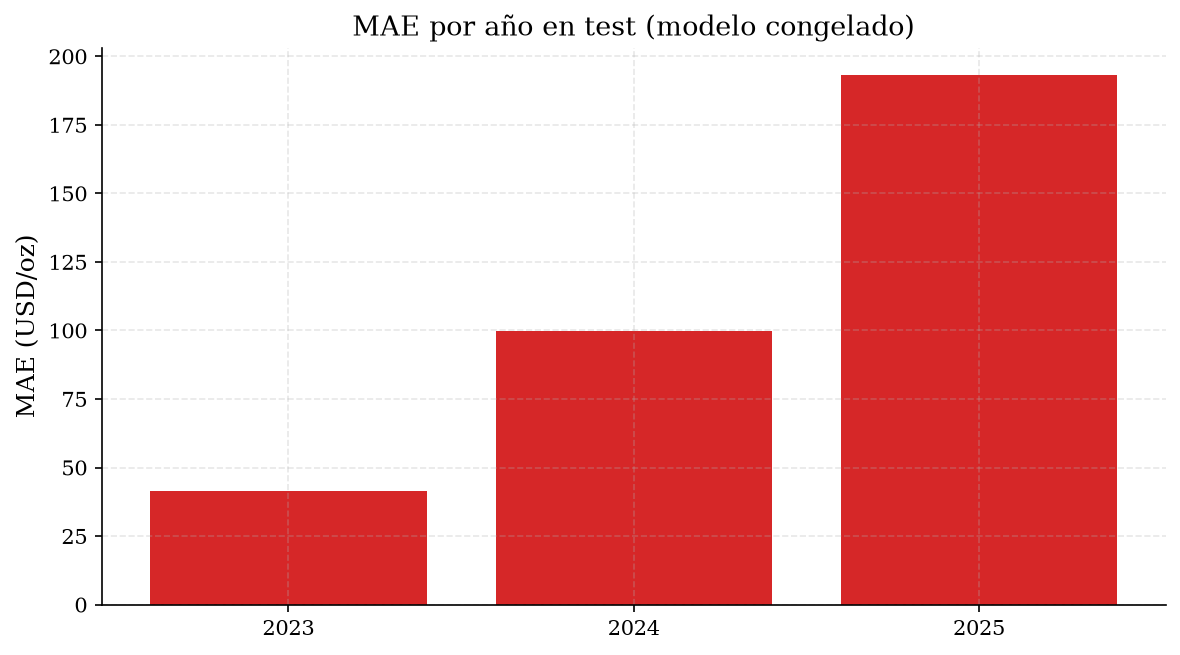

In [4]:
import matplotlib.pyplot as plt

from src.utils import save_fig

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(perf.index.astype(str), perf["mae"], color="#d62728")
ax.set_title("MAE por año en test (modelo congelado)")
ax.set_ylabel("MAE (USD/oz)")
fig.tight_layout()
save_fig(fig, "robustness_by_year.png")

19.2 Covariate shift (KS test) entre train y test.

Comparamos la distribución de cada feature en train+val contra test con el
test de Kolmogorov-Smirnov. p < 0.01 indica drift significativo.

In [5]:
from statsmodels.stats.multitest import multipletests

train_val = pd.concat([parts["train"], parts["val"]]).sort_values("date").reset_index(drop=True)
key_feats = sel_cols
raw_shift = []
for c in key_feats:
    stat, p_value = ks_2samp(train_val[c].dropna().to_numpy(), te[c].dropna().to_numpy())
    raw_shift.append((c, float(stat), float(p_value)))
reject, p_adj, _, _ = multipletests(
    [p_value for _, _, p_value in raw_shift], alpha=0.01, method="fdr_bh"
)
shift = {
    c: {"ks_stat": stat, "p_value": p_value, "p_value_bh": float(adj), "drift_bh": bool(flag)}
    for (c, stat, p_value), flag, adj in zip(raw_shift, reject, p_adj)
}
print("Covariate shift (KS con correccion BH) en todas las features:")
for c, v in shift.items():
    flag = "DRIFT" if v["drift_bh"] else "ok"
    print(f"  {c:35s} KS={v['ks_stat']:.3f} p={v['p_value']:.4g} "
          f"p_BH={v['p_value_bh']:.4g} {flag}")

save_json({"segment_performance": perf[["mae", "smape", "directional_accuracy"]].round(3).to_dict("index"),
           "covariate_shift": shift,
           "multiple_testing": {"method": "fdr_bh", "alpha": 0.01, "n_features": len(key_feats)}},
          "robustness.json")

Covariate shift (KS) en features clave:
  us10y_yield                         KS=0.574 p=0.0000 DRIFT
  policy_uncertainty                  KS=0.219 p=0.0000 DRIFT
  geopolitical_risk                   KS=0.367 p=0.0000 DRIFT
  usdjpy_exchange                     KS=0.952 p=0.0000 DRIFT
  eurusd_exchange                     KS=0.605 p=0.0000 DRIFT
  us2y_yield                          KS=0.827 p=0.0000 DRIFT
  usdinr_exchange                     KS=0.988 p=0.0000 DRIFT
  dxy_index                           KS=0.764 p=0.0000 DRIFT
  silver_spot                         KS=0.753 p=0.0000 DRIFT
  usdcny_exchange                     KS=0.502 p=0.0000 DRIFT
  palladium_spot                      KS=0.739 p=0.0000 DRIFT
  platinum_spot                       KS=0.335 p=0.0000 DRIFT
  brent_spot                          KS=0.501 p=0.0000 DRIFT
  copper_futures                      KS=0.805 p=0.0000 DRIFT
  vix_index                           KS=0.229 p=0.0000 DRIFT
[json] C:\Users\sgml1\Desktop\

WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction/reports/robustness.json')

20. Ética, privacidad y seguridad.

El dataset no contiene datos personales ni variables sensibles (son series
de mercado públicas). No hay grupos demográficos afectados, por lo que el
análisis de equidad por subgrupos no aplica.

Medidas de seguridad implementadas:
- Validación estricta de inputs en la API (Pydantic + rechazo de NaN/Inf/claves extra).
- Sin secretos en el repositorio (`.env` ignorado).
- Dependencias declaradas con cotas minimas en `requirements.txt`; la reproduccion exacta requiere lockfile.
- Uso previsto documentado: analítico, NO trading automático sin supervisión.

Este bloque es informativo; no ejecuta código.

In [6]:
print("""
Checklist fase 20:
[OK] Sin datos personales ni variables sensibles
[OK] Sin secretos en el repo (.env ignorado)
[OK] Validación de inputs en API (Pydantic + finitos)
[OK] Uso previsto documentado (analítico, no trading automático)
[INFO] Dependencias con cotas minimas; reproduccion exacta requiere lockfile
""")


Checklist fase 20:
[OK] Sin datos personales ni variables sensibles
[OK] Sin secretos en el repo (.env ignorado)
[OK] Validación de inputs en API (Pydantic + finitos)
[OK] Uso previsto documentado (analítico, no trading automático)
[OK] Dependencias fijadas en requirements.txt

